# Data cleaning

## Comenzaré con una pre-limpieza de los datos (scrubbing o depuración) para posteriormente pasar al EDA.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("ventas_empresa_logistica.csv")

In [2]:
df.head()

,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,total,vendedor,region,canal,metodo_pago
0,2023-09-30,CLI-5668,Papas precocinadas,Congelados,1,2.3,2.3,NaN,NaN,NaN,Tarjeta crédito
1,2024-10-31,CLI-6740,Bolsas plásticas,Descartables,19,0.1,1.9,NaN,NaN,Tienda física,Tarjeta débito
2,14/09/2024,CLI-7971,Leche entera,Lácteos,4,1.2,4.8,Yonny,NaN,Teléfono,Tarjeta débito
3,2023-11-27,NaN,Papas precocinadas,Congelados,2,2.3,4.6,Lili,NaN,Teléfono,QR
4,2023-12-12,CLI-3001,Leche entera,Lácteos,1,1.2,1.2,Lili,NaN,Tienda física,QR


In [3]:
print(df.shape)

(28358, 11)


Bueno, tenemos 28358 filas y 11 columnas. Continuamos pre-análisis.

In [4]:
df.describe()

,cantidad,precio_unitario,total,region
count,28358.000000,28358.000000,28358.000000,0.0
mean,2.953911,2.133867,3.736900,NaN
std,2.620760,1.824096,3.031758,NaN
min,1.000000,0.100000,0.100000,NaN
25%,1.000000,0.750000,1.200000,NaN
50%,2.000000,1.200000,3.200000,NaN
75%,4.000000,4.000000,4.600000,NaN
max,19.000000,5.800000,29.000000,NaN


In [5]:
#Este método .info() nos es útil para ver un pequeño resumen del DataFrame.
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 28358 entries, 0 to 28357
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   fecha            28358 non-null  str    
 1   cliente_id       19885 non-null  str    
 2   producto         28358 non-null  str    
 3   categoria        28358 non-null  str    
 4   cantidad         28358 non-null  int64  
 5   precio_unitario  28358 non-null  float64
 6   total            28358 non-null  float64
 7   vendedor         16694 non-null  str    
 8   region           0 non-null      float64
 9   canal            26600 non-null  str    
 10  metodo_pago      25018 non-null  str    
dtypes: float64(3), int64(1), str(7)
memory usage: 2.4 MB


In [6]:
#I can see there is some nulls in the DataFrame

In [7]:
#Let´s analyze the Nones, NaN or null values
df.isnull().sum()

fecha                  0
cliente_id          8473
producto               0
categoria              0
cantidad               0
precio_unitario        0
total                  0
vendedor           11664
region             28358
canal               1758
metodo_pago         3340
dtype: int64

Se confirma la presencia de nulos. Deben ser tratado según se acuerde con el cliente para
establecer qué se identificaría como una venta nula o no.

Según retroalimentación con el cliente, una venta es inválida si:  
-fecha es nula  
-método_pago es nula

In [8]:
df_save = df
df = df.dropna(subset=['fecha','metodo_pago']) #Solo elimino nulos de esas dos columnas

In [9]:
#Let´s analyze the Nones, NaN or null values again, should be seen metodo_pago and date sum of null = 0
df.isnull().sum()

fecha                  0
cliente_id          7477
producto               0
categoria              0
cantidad               0
precio_unitario        0
total                  0
vendedor           10307
region             25018
canal               1547
metodo_pago            0
dtype: int64

In [10]:
print(df.shape)

(25018, 11)


## Deduplication

Antes de proceder con el procesamiento de duplicados se conversa con el cliente y se analiza el sistema en uso. 
Este sistema registra al final del día la venta de los productos sumando las cantidades, es decir, si se 
vendió en la fecha X, 15 unidades de un producto A en diferentes horarios del día, al cierre contable diario debe quedar,
en teoría, una sola fila de 15 unidades vendidas de un producto A. Esto se debe mejorar como sistema y se señalará al final del proyecto.

In [11]:
#Detección de duplicados
print('Tenemos :',df.duplicated().sum(),' duplicados.')

Tenemos : 769  duplicados.


In [12]:
duplicated = df[df.duplicated(keep=False)]

In [13]:
#with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.width', None,'expand_frame_repr', False):
#    print(duplicated.sort_values(by=['fecha', 'producto', 'cantidad']))

In [14]:
df = df.drop_duplicates()

#Consultamos si quedan duplicados ahora:
#Para ello seguimos usando el dataframe.
print('Tenemos :',df.duplicated().sum(),' duplicados.')

Tenemos : 0  duplicados.


In [15]:
#Let´s see the shape again
df.shape

(24249, 11)

Se pueden cambiar tipos de datos (la columna fecha), y codificar algunas columnas.

### Changing data type in 'fecha' column to datetime

In [16]:
df['fecha'].dtypes

<StringDtype(storage='python', na_value=nan)>

Aclaración, se usa Little Endian en fechas.

In [17]:
# Combinamos mixed con dayfirst
df['fecha'] = pd.to_datetime(df['fecha'], dayfirst=True, format='mixed')

In [18]:
df['fecha'].dtypes

dtype('<M8[us]')

In [19]:
df['fecha'].head(5)

0   2023-09-30
1   2024-10-31
2   2024-09-14
3   2023-11-27
4   2023-12-12
Name: fecha, dtype: datetime64[us]

In [20]:
#Tipo de dato fecha establecido con éxito.

### Useless columns identification

In [21]:
#Necesito identificar si existe alguna columna que no sea relevante para el análisis.

In [22]:
df.head(7)

,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,total,vendedor,region,canal,metodo_pago
0,2023-09-30,CLI-5668,Papas precocinadas,Congelados,1,2.3,2.3,NaN,NaN,NaN,Tarjeta crédito
1,2024-10-31,CLI-6740,Bolsas plásticas,Descartables,19,0.1,1.9,NaN,NaN,Tienda física,Tarjeta débito
2,2024-09-14,CLI-7971,Leche entera,Lácteos,4,1.2,4.8,Yonny,NaN,Teléfono,Tarjeta débito
3,2023-11-27,NaN,Papas precocinadas,Congelados,2,2.3,4.6,Lili,NaN,Teléfono,QR
4,2023-12-12,CLI-3001,Leche entera,Lácteos,1,1.2,1.2,Lili,NaN,Tienda física,QR
5,2023-12-16,CLI-3222,Pollo entero,Carnes,1,4.5,4.5,NaN,NaN,Teléfono,Tarjeta crédito
6,2024-05-11,NaN,Yogurt natural,Lácteos,2,0.9,1.8,NaN,NaN,E-commerce,Transferencia


In [23]:
df['region'].unique()

array([nan])

In [24]:
#Esta columna 'region' está vacía, no aporta nada, por tanto será eliminada.
df = df.drop(columns='region')

In [25]:
df.head(1)

,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,total,vendedor,canal,metodo_pago
0,2023-09-30,CLI-5668,Papas precocinadas,Congelados,1,2.3,2.3,NaN,NaN,Tarjeta crédito


In [26]:
df['vendedor'].unique()  #Se desestima por poco aporte al análisis

<StringArray>
[nan, 'Yonny', 'Lili']
Length: 3, dtype: str

In [27]:
df = df.drop(columns='vendedor')

In [28]:
df.head(1)

,fecha,cliente_id,producto,categoria,cantidad,precio_unitario,total,canal,metodo_pago
0,2023-09-30,CLI-5668,Papas precocinadas,Congelados,1,2.3,2.3,NaN,Tarjeta crédito


In [29]:
df['canal'].unique()

<StringArray>
[nan, 'Tienda física', 'Teléfono', 'E-commerce']
Length: 4, dtype: str

In [30]:
cantNulos = df['canal'].isnull().sum()
totalFilas = df['canal'].shape[0]
percent = (cantNulos*100)/totalFilas
percent

6.1940698585508684

A pesar de que en la columna 'canal' la cantidad de  nulos existentes solo representa un 6.19%.
Se desestima por poco aporte al análisis.

In [31]:
df = df.drop(columns='canal')

#Dado que en el lugar del negocio no existían hasta la fecha de estudio tarjetas de crédito, todos los valores de método de pago que sean tarjéta de crédito se referirán a pago con débito.
#Al momento del análisis no existe un programa de seguimiento uno a uno con los clientes, por tanto no se tomará para análisis el id de los clientes y pactado con el cliente no se incluiría en el presupuesto.
df = df.drop(columns = 'cliente_id')

In [32]:
df.head(5)

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago
0,2023-09-30,Papas precocinadas,Congelados,1,2.3,2.3,Tarjeta crédito
1,2024-10-31,Bolsas plásticas,Descartables,19,0.1,1.9,Tarjeta débito
2,2024-09-14,Leche entera,Lácteos,4,1.2,4.8,Tarjeta débito
3,2023-11-27,Papas precocinadas,Congelados,2,2.3,4.6,QR
4,2023-12-12,Leche entera,Lácteos,1,1.2,1.2,QR


### Procesamiento de outliers

In [33]:
# Verificar discrepancias de cálculo
diferencia = (df['cantidad'] * df['precio_unitario']) - df['total']
errores_calculo = df[diferencia.abs() > 0.01] # Tolerancia por decimales
print(errores_calculo)

Empty DataFrame
Columns: [fecha, producto, categoria, cantidad, precio_unitario, total, metodo_pago]
Index: []


El hecho que el resultado anterior sea un DataFrame vacío implica que no existiría un outlier técnico en la columna total, siendo los valores correctos: (cantidad * precio_unitario)=total

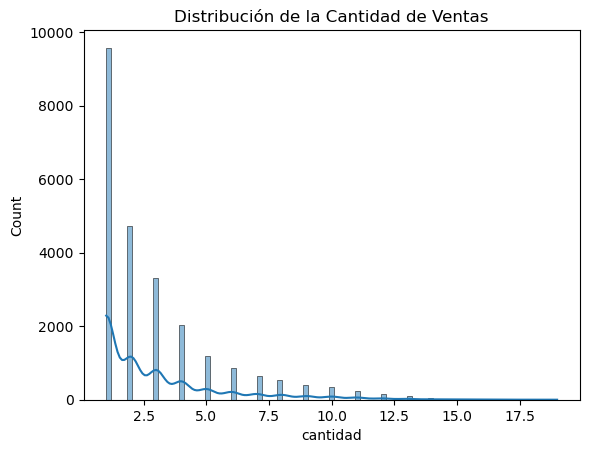

In [34]:
#Before outliers analysis let´s take a look to the distribution of 'cantidad' column
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['cantidad'], kde=True)
plt.title('Distribución de la Cantidad de Ventas')
plt.show()

In [35]:
#apreciamos un sesgo a la derecha, no es distribución normal, sin embargo sigamos protocolos
df['cantidad'].skew()

1.8887526654425604

La simetría es mayo a cero.

In [36]:
df['cantidad'].kurtosis()

3.772176815046997

Con estos valores y representación visual nos damos cuenta que no es una distribución normal, más bien presenta un sesgo a la derecha (cola), se usará IQR (Rango Intercuartílico) para la detección de outliers.

Taking a look with box plots:

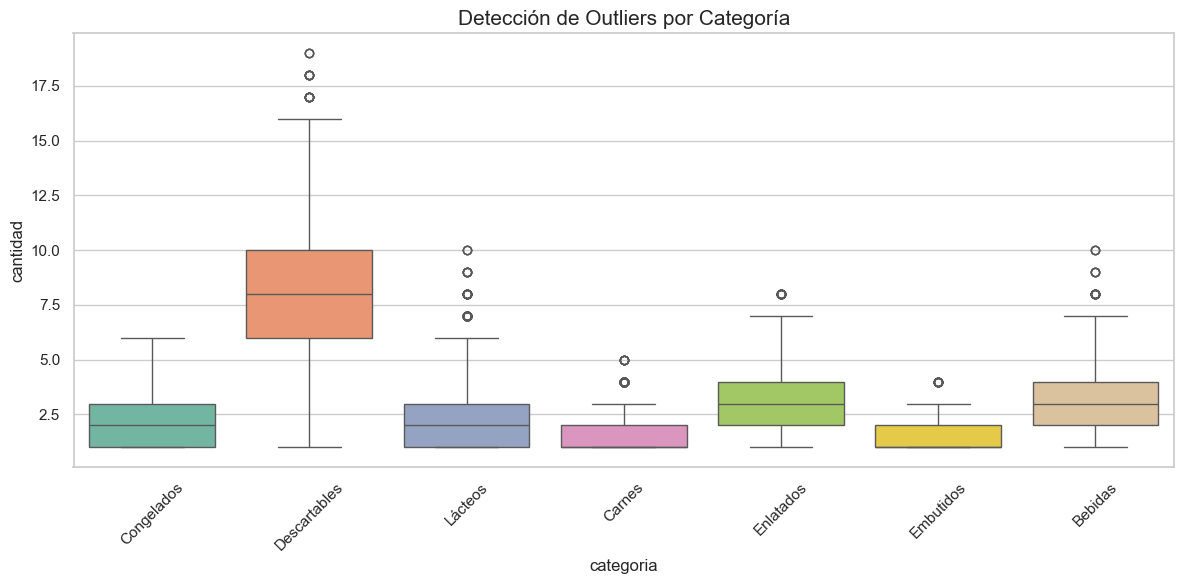

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 'categoria' a 'hue' y legend en False porque ya está en el eje X
ax = sns.boxplot(
    data=df, 
    x='categoria', 
    y='cantidad', 
    hue='categoria', 
    palette='Set2', 
    legend=False
)

# 3. Estética
plt.title('Detección de Outliers por Categoría', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

In [38]:
import pandas as pd

def identificar_outliers_iqr(df, columna_num, columna_cat):
    # 1. Calcular Q1 y Q3 por cada categoría
    q1 = df.groupby(columna_cat)[columna_num].transform(lambda x: x.quantile(0.25))
    q3 = df.groupby(columna_cat)[columna_num].transform(lambda x: x.quantile(0.75))
    
    # 2. Calcular el IQR
    iqr = q3 - q1
    
    # 3. Definir los límites
    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr
    
    # 4. Crear una máscara booleana (True si es outlier)
    outliers_mask = (df[columna_num] < limite_inferior) | (df[columna_num] > limite_superior)
    
    return outliers_mask

# Aplicar la función a tu DataFrame
df['es_outlier'] = identificar_outliers_iqr(df, 'cantidad', 'categoria')

# Filtrar para VER solo los outliers
df_outliers = df[df['es_outlier'] == True]

print(f"Se detectaron {df_outliers.shape[0]} outliers.")
print(df_outliers.head())

Se detectaron 273 outliers.
         fecha          producto     categoria  cantidad  precio_unitario  \
1   2024-10-31  Bolsas plásticas  Descartables        19             0.10   
41  2023-12-30   Pasta de Tomate     Enlatados         8             0.75   
112 2023-09-14    Yogurt natural       Lácteos         8             0.90   
150 2023-02-08       Refresco 2L       Bebidas         8             1.10   
195 2024-10-25      Pollo entero        Carnes         4             4.50   

     total      metodo_pago  es_outlier  
1      1.9   Tarjeta débito        True  
41     6.0  Tarjeta crédito        True  
112    7.2               QR        True  
150    8.8               QR        True  
195   18.0  Tarjeta crédito        True  


Confirmo presencia de Outliars pero son valores reales de ventas registrados.

In [39]:
fechas_especiales = [
    # --- 2023 ---
    '2023-01-01', '2023-01-02', # Triunfo de la Rev. y Victoria
    '2023-02-14', # San Valentín
    '2023-03-08', # Día de la Mujer
    '2023-05-14', # Día de las Madres (2do domingo)
    '2023-06-18', # Día de los Padres (3er domingo)
    '2023-07-25', '2023-07-26', '2023-07-27', # Festividades del 26 de Julio
    '2023-08-13', # Natalicio de Fidel
    '2023-12-24', '2023-12-25', '2023-12-31', # Navidad y Fin de Año

    # --- 2024 ---
    '2024-01-01', '2024-01-02',
    '2024-02-14',
    '2024-03-08',
    '2024-05-12', # Día de las Madres (2do domingo)
    '2024-06-16', # Día de los Padres (3er domingo)
    '2024-07-25', '2024-07-26', '2024-07-27',
    '2024-08-13',
    '2024-12-24', '2024-12-25', '2024-12-31',]


In [40]:
fechas_especiales = pd.to_datetime(fechas_especiales)

In [41]:
outliers_legitimos = df_outliers[df_outliers['fecha'].isin(fechas_especiales)]

In [42]:
outliers_legitimos

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier
2806,2024-07-25,Yogurt natural,Lácteos,10,0.9,9.0,QR,True
12028,2024-07-27,Yogurt natural,Lácteos,7,0.9,6.3,Tarjeta crédito,True
13933,2024-07-25,Refresco 2L,Bebidas,9,1.1,9.9,QR,True
15629,2023-07-26,Pollo entero,Carnes,4,4.5,18.0,Tarjeta crédito,True
16159,2023-07-26,Yogurt natural,Lácteos,8,0.9,7.2,Transferencia,True
19975,2023-07-27,Refresco 2L,Bebidas,8,1.1,8.8,Tarjeta crédito,True
21603,2023-07-25,Yogurt natural,Lácteos,7,0.9,6.3,Efectivo,True


In [43]:
outliers_ruido = df_outliers[~df_outliers['fecha'].isin(fechas_especiales)]

In [44]:
outliers_ruido

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier
1,2024-10-31,Bolsas plásticas,Descartables,19,0.10,1.9,Tarjeta débito,True
41,2023-12-30,Pasta de Tomate,Enlatados,8,0.75,6.0,Tarjeta crédito,True
112,2023-09-14,Yogurt natural,Lácteos,8,0.90,7.2,QR,True
150,2023-02-08,Refresco 2L,Bebidas,8,1.10,8.8,QR,True
195,2024-10-25,Pollo entero,Carnes,4,4.50,18.0,Tarjeta crédito,True
...,...,...,...,...,...,...,...,...
27858,2024-04-13,Yogurt natural,Lácteos,7,0.90,6.3,Efectivo,True
27921,2023-10-14,Jamón de pavo,Embutidos,4,3.20,12.8,Efectivo,True
28027,2023-05-29,Pollo entero,Carnes,4,4.50,18.0,Tarjeta débito,True
28028,2024-09-14,Pollo entero,Carnes,4,4.50,18.0,Efectivo,True


Estos valores "outliers" son valores reales del negocio, eliminarlos o caparlos sería un error técnico donde perdería información.
Tratamiento a outliers usando una columna logarítmica, dado que si los trato mediante un tope en los quartiles cortaría datos reales que deben ser considerados a futuro:

In [45]:
import numpy as np

#Aquí crearé la columna nueva
df["cantidad_log"] = np.log1p(df["cantidad"])


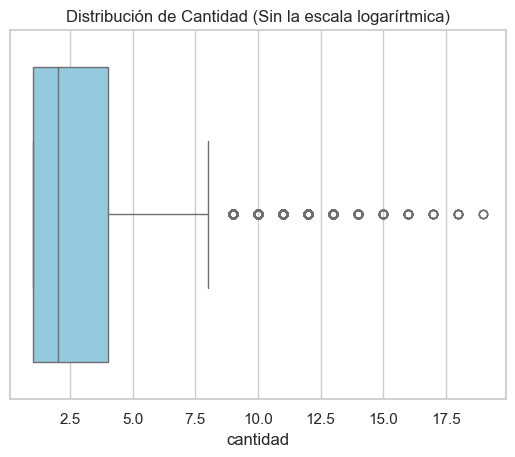

In [46]:
import seaborn as sns

plt.figure()

sns.boxplot(x=df["cantidad"], color = "skyblue")
plt.title('Distribución de Cantidad (Sin la escala logarírtmica)')
plt.show()

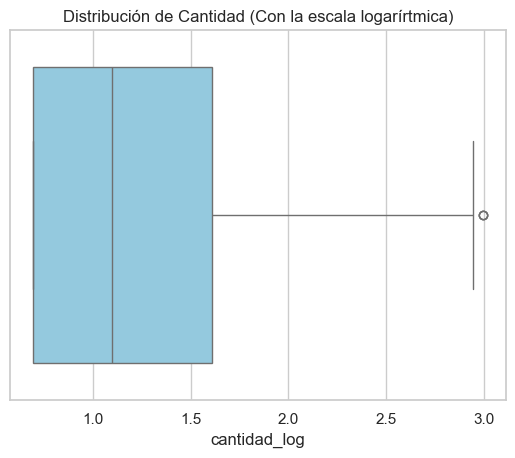

In [47]:
#Veamos el resultado de cómo se ve ahora: 
#uso nuevamente seaborn
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure()

sns.boxplot(x=df["cantidad_log"], color = "skyblue")
plt.title('Distribución de Cantidad (Con la escala logarírtmica)')
plt.show()

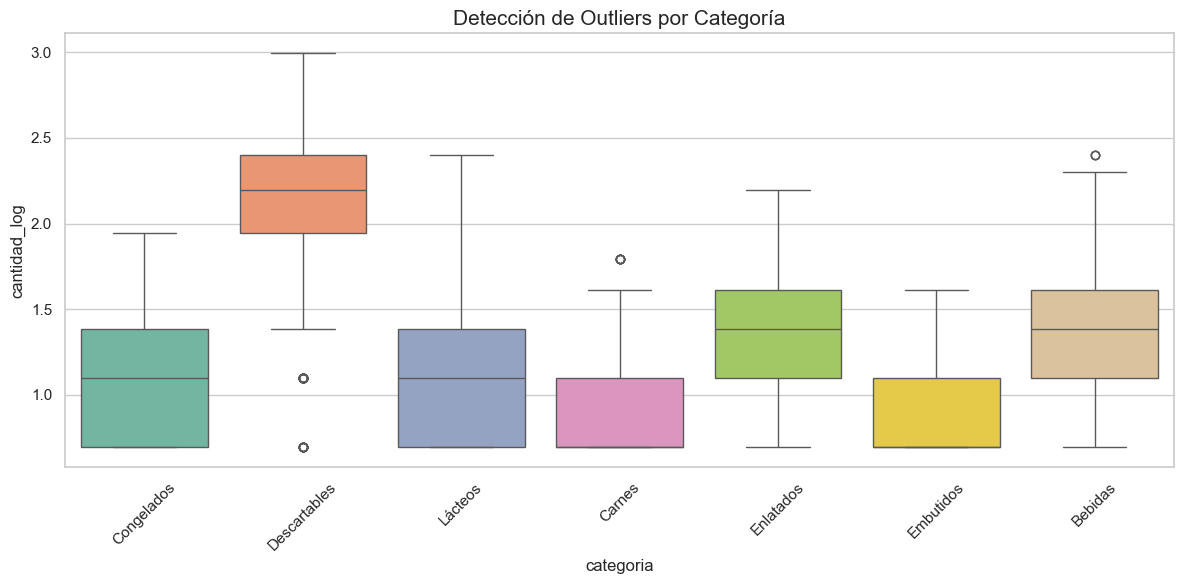

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 6))

# 'categoria' a 'hue' y legend en False porque ya está en el eje X
ax = sns.boxplot(
    data=df, 
    x='categoria', 
    y='cantidad_log', 
    hue='categoria', 
    palette='Set2', 
    legend=False
)

# 3. Estética
plt.title('Detección de Outliers por Categoría', fontsize=15)
plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

Después de la transformación logarítmica de la variable "cantidad", 
observo ausencia outliers y más estabilidad en los valores.

In [49]:
#Primero visualicemos otros datos extremos
# Calculamos el límite superior del boxplot
Q1 = df['cantidad_log'].quantile(0.25)
Q3 = df['cantidad_log'].quantile(0.75)
IQR = Q3 - Q1
limite_superior = Q3 + 1.5 * IQR

# Filtramos los que REALMENTE son outliers según el gráfico
df_extremos = df[df['cantidad_log'] > limite_superior]

# Creamos el dataframe limpio (sin esos puntos)
df_limpio = df[df['cantidad_log'] <= limite_superior]

print(f"Datos originales: {len(df)}")
print(f"Outliers detectados: {len(df_extremos)}")

Datos originales: 24249
Outliers detectados: 3


In [50]:
df_extremos

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier,cantidad_log
1,2024-10-31,Bolsas plásticas,Descartables,19,0.1,1.9,Tarjeta débito,True,2.995732
16121,2023-06-05,Bolsas plásticas,Descartables,19,0.1,1.9,QR,True,2.995732
27011,2023-09-30,Bolsas plásticas,Descartables,19,0.1,1.9,Tarjeta débito,True,2.995732


Tenemos un dataframe más estabilizado.
Anotación: Revertir la escala logarítmica en resultados posteriores.

Resultados de limpieza de datos:

- 3340 Ventas inválidas detectadas
- 734  duplicados eliminados
- Tipo de dato de columna 'fecha' corregido.
- 4 Columnas irrelevantes eliminadas.
- Detectados valores posiblemente outliers y tratados con escala logarítmica.
- Creada la columna cantidad_log para el entrenamiento del modelo.

#### Guardemos el df modificado en un nuevo archivo:

In [51]:
df.head(8)

,fecha,producto,categoria,cantidad,precio_unitario,total,metodo_pago,es_outlier,cantidad_log
0,2023-09-30,Papas precocinadas,Congelados,1,2.3,2.3,Tarjeta crédito,False,0.693147
1,2024-10-31,Bolsas plásticas,Descartables,19,0.1,1.9,Tarjeta débito,True,2.995732
2,2024-09-14,Leche entera,Lácteos,4,1.2,4.8,Tarjeta débito,False,1.609438
3,2023-11-27,Papas precocinadas,Congelados,2,2.3,4.6,QR,False,1.098612
4,2023-12-12,Leche entera,Lácteos,1,1.2,1.2,QR,False,0.693147
5,2023-12-16,Pollo entero,Carnes,1,4.5,4.5,Tarjeta crédito,False,0.693147
6,2024-05-11,Yogurt natural,Lácteos,2,0.9,1.8,Transferencia,False,1.098612
7,2023-03-17,Carne molida,Carnes,1,5.8,5.8,Tarjeta crédito,False,0.693147


In [52]:
df.to_csv("clean_data.csv")